# PyChronux multitaper spectral analysis

This tutorial is a practical tour of every function in `neuro_py.process.pychronux`. It uses deterministic synthetic data, so it can be run without a recording session. We will estimate oscillatory power in spike trains and continuous signals, then quantify frequency-specific coupling between two spike trains.

## Why multitaper?

A periodogram made with one window can be noisy and can leak power from a strong rhythm into nearby frequencies. Multitaper methods instead multiply the same observation by several **DPSS (Slepian) tapers**, compute one Fourier transform per taper, and average the resulting estimates. The tapers are optimized to concentrate energy in a chosen bandwidth, reducing estimator variance while controlling leakage.

The central tuning choice is the time-bandwidth product `NW`. Larger `NW` supports more useful tapers (roughly `2 * NW - 1`) and produces a more stable estimate, but smooths together more closely spaced frequencies. Longer data improve the intrinsic resolution; zero-padding only samples the same estimate on a finer frequency grid.

In [1]:
%matplotlib inline
from fractions import Fraction
from pathlib import Path

import matplotlib.pyplot as plt
import nelpy as nel
import numpy as np
import pandas as pd
from scipy.signal import resample_poly
from scipy.signal.windows import dpss

import neuro_py as npy
from neuro_py.process import pychronux as px

rng = np.random.default_rng(20260723)
fs = 1_000  # Hz; spike-time grid and continuous-signal sampling rate
duration = 10.0  # seconds
target_frequency = 8.0  # Hz
fpass = [1.0, 40.0]
NW, n_tapers = 3, 5

## 1. Foundations: frequency grids and DPSS tapers

Use `getfgrid(Fs, nfft, fpass)` when you need the frequency values and Boolean FFT mask used by the lower-level routines. `Fs` is in Hz, `nfft` is the FFT length, and `fpass` is the inclusive frequency range in Hz. The returned `f` has units of Hz; `findx` indexes an FFT with length `nfft`.

Use `dpsschk((NW, K), N, Fs)` for the Chronux-style taper layout needed by `mtfftc` and `mtfftpt`: `(N samples, K tapers)`, scaled for `Fs`. Use `get_tapers(N, bandwidth, fs=...)` when you want to specify physical bandwidth in Hz and inspect concentration ratios. It returns `(K tapers, N samples)`, so transpose it before passing it to the lower-level FFT routines.

In [2]:
n_samples = int(duration * fs)
nfft = 2 ** int(np.ceil(np.log2(n_samples)))
frequencies, findx = px.getfgrid(fs, nfft, fpass)
chronux_tapers = px.dpsschk((NW, n_tapers), n_samples, fs)
bandwidth_hz = NW * fs / n_samples
tapers_k_by_n, lambdas = px.get_tapers(n_samples, bandwidth_hz, fs=fs, n_tapers=4)

assert chronux_tapers.shape == (n_samples, n_tapers)
assert tapers_k_by_n.shape == (4, n_samples)
assert frequencies[0] >= fpass[0] and frequencies[-1] <= fpass[-1]
print(f"Frequency spacing: {fs / nfft:.3f} Hz")
print(f"get_tapers concentration ratios: {lambdas.round(4)}")

Frequency spacing: 0.061 Hz
get_tapers concentration ratios: [1.     1.     0.9997 0.9949]


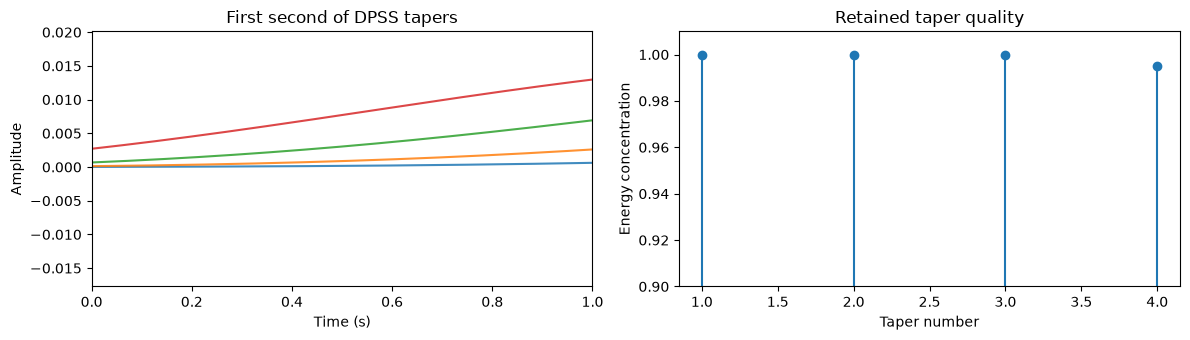

In [3]:
time = np.arange(n_samples) / fs
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for taper in tapers_k_by_n:
    axes[0].plot(time, taper, alpha=0.85)
axes[0].set(
    xlim=(0, 1),
    xlabel="Time (s)",
    ylabel="Amplitude",
    title="First second of DPSS tapers",
)
axes[1].stem(np.arange(1, len(lambdas) + 1), lambdas)
axes[1].set(
    xlabel="Taper number",
    ylabel="Energy concentration",
    ylim=(0.9, 1.01),
    title="Retained taper quality",
)
plt.tight_layout()

**Choosing parameters.** Choose `fs` to match the sampling grid used to represent the data. For point processes it defines the interpolation/grid resolution, not a spike-sampling rate. Choose `NW` according to the frequency separation you need to resolve; `NW=3` is a useful starting point for a stable broad-band estimate. Do not request more tapers than the concentration criterion supports. Restrict `fpass` before interpretation, but ensure it is below the Nyquist frequency (`fs / 2`).

## 2. Point processes: rhythmic spiking, power, and coupling

We simulate two neurons that fire short bursts every 125 ms (8 Hz). Their individual spike times are in **seconds**. The independent jitter makes the example more realistic while retaining a known rhythm. `time_support=[0, duration]` is important: it defines the observation window, including intervals with no spikes, and therefore the rate baseline.

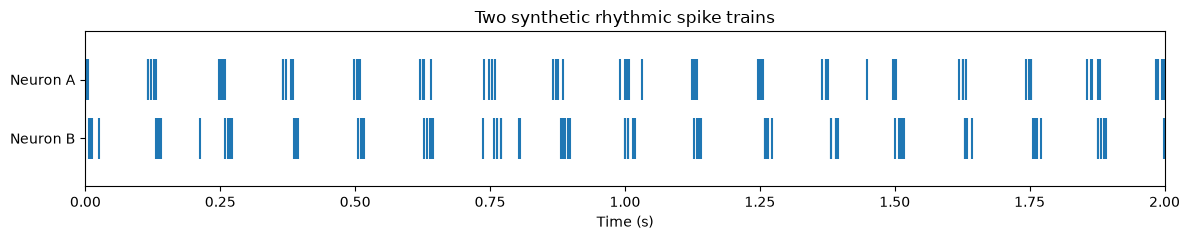

In [4]:
def make_burst_train(random_generator, phase_s=0.0):
    """Return an 8-Hz burst-modulated spike train in seconds."""
    centers = np.arange(phase_s, duration, 1 / target_frequency)
    bursts = [center + random_generator.normal(0, 0.006, size=5) for center in centers]
    spikes = np.concatenate(bursts)
    background = random_generator.uniform(0, duration, size=25)
    return np.sort(
        np.concatenate((spikes, background))[
            (np.concatenate((spikes, background)) >= 0)
            & (np.concatenate((spikes, background)) <= duration)
        ]
    )


spikes_a = make_burst_train(rng)
spikes_b = make_burst_train(rng, phase_s=0.012)
spike_trains = [spikes_a, spikes_b]

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.eventplot([spikes_a, spikes_b], lineoffsets=[1, 0], linelengths=0.7)
ax.set(
    xlim=(0, 2),
    yticks=[0, 1],
    yticklabels=["Neuron B", "Neuron A"],
    xlabel="Time (s)",
    title="Two synthetic rhythmic spike trains",
)
plt.tight_layout()

### The point-process transform: `mtfftpt`

`mtfftpt(data, tapers, nfft, t, f, findx)` is the building block for point-process spectra. It returns complex tapered transforms `J` with shape `(n_frequencies, n_tapers)`, mean spikes per time-grid sample `Msp`, and spike count `Nsp`. Use it when you need custom spectral quantities; otherwise prefer the higher-level estimators below. Its inputs require a one-dimensional spike-time array, a `(N, K)` taper matrix, and a time grid `t` in seconds.

In [5]:
taper_times = np.arange(-1 / fs, duration + 1 / fs, 1 / fs)
point_tapers = px.dpsschk((NW, n_tapers), len(taper_times), fs)
point_nfft = 2 ** int(np.ceil(np.log2(len(taper_times))))
point_frequencies, point_findx = px.getfgrid(fs, point_nfft, fpass)
J, mean_spikes_per_sample, spike_count = px.mtfftpt(
    spikes_a, point_tapers, point_nfft, taper_times, point_frequencies, point_findx
)
assert J.shape == (len(point_frequencies), n_tapers)
assert spike_count == len(spikes_a)
print(
    f"J shape: {J.shape}; spike count: {spike_count}; mean grid count: {mean_spikes_per_sample:.4f}"
)

J shape: (639, 5); spike count: 422; mean grid count: 0.0422


### Point-process power: `mtspectrumpt` and `point_spectra`

Use `mtspectrumpt` for one or more spike trains. It returns a pandas `DataFrame`: frequency in Hz is the index and each column is one input train. It is the most convenient choice for comparing units or reusing precomputed tapers/time grids. `point_spectra` is a compact single-train alternative returning `(power, frequencies)` NumPy arrays. Both answer: *at which frequencies is a spike train rhythmically modulated?* Power alone does not establish coupling to another signal.

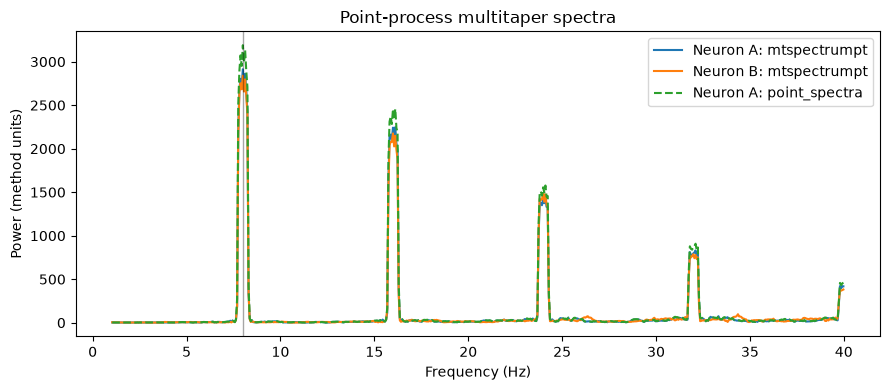

In [6]:
point_power = px.mtspectrumpt(
    spike_trains, fs, fpass, NW=NW, n_tapers=n_tapers, time_support=[0, duration]
)
single_power, single_frequencies = px.point_spectra(
    spikes_a, Fs=fs, freq_range=fpass, tapers0=[NW, n_tapers]
)
peak_frequency = float(point_power.index[np.argmax(point_power.iloc[:, 0].to_numpy())])
assert point_power.shape[1] == 2
assert abs(peak_frequency - target_frequency) < 1.0
assert single_power.shape == single_frequencies.shape

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(point_power.index, point_power.iloc[:, 0], label="Neuron A: mtspectrumpt")
ax.plot(point_power.index, point_power.iloc[:, 1], label="Neuron B: mtspectrumpt")
ax.plot(single_frequencies, single_power, "--", label="Neuron A: point_spectra")
ax.axvline(target_frequency, color="k", alpha=0.35, lw=1)
ax.set(
    xlabel="Frequency (Hz)",
    ylabel="Power (method units)",
    title="Point-process multitaper spectra",
)
ax.legend()
plt.tight_layout()

### Pairwise spectra: `mtcsdpt` and `mtcoherencept`

`mtcsdpt` returns a one-column `DataFrame` named `CSD` indexed by Hz. Cross-spectral density preserves the signed real cross-spectral component implemented here and is useful for describing shared spectral structure. `mtcoherencept` normalizes cross-spectral power by each train's power and returns a `Coherence` column. Use coherence to ask whether two spike trains have consistent frequency-specific coupling, especially when their overall powers differ. A coherence peak is not evidence of causality, directionality, or a direct synaptic connection; shared input and task structure can produce it.

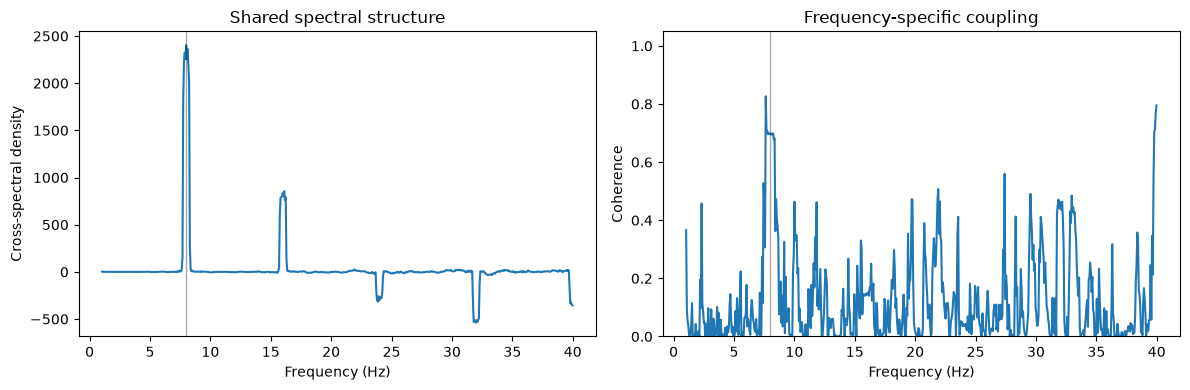

In [7]:
csd = px.mtcsdpt(
    spikes_a, spikes_b, fs, fpass, NW=NW, n_tapers=n_tapers, time_support=[0, duration]
)
coherence = px.mtcoherencept(
    spikes_a, spikes_b, fs, fpass, NW=NW, n_tapers=n_tapers, time_support=[0, duration]
)
assert list(csd.columns) == ["CSD"]
assert list(coherence.columns) == ["Coherence"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(csd.index, csd["CSD"])
axes[0].set(
    xlabel="Frequency (Hz)",
    ylabel="Cross-spectral density",
    title="Shared spectral structure",
)
axes[1].plot(coherence.index, coherence["Coherence"])
axes[1].set(
    xlabel="Frequency (Hz)",
    ylabel="Coherence",
    ylim=(0, 1.05),
    title="Frequency-specific coupling",
)
for ax in axes:
    ax.axvline(target_frequency, color="k", alpha=0.35, lw=1)
plt.tight_layout()

**Point-process caveats.** Spike times must use seconds and be sorted. Specify `time_support` whenever the recorded support is known, especially if the first/last spike does not mark the true recording boundary. Do not compare raw power across different supports, rates, or taper settings without accounting for those differences. Empty input to `mtspectrumpt` returns an empty DataFrame; inspect that condition before plotting.

## 3. Continuous data: LFP-like power

For uniformly sampled data such as LFP, use `mtfftc(data, tapers, nfft, Fs)` for the complex tapered Fourier transforms and `mtspectrumc(data, Fs, fpass, tapers)` for the high-level power spectrum. The signal is a one-dimensional sample vector; `mtfftc` requires tapers shaped `(N samples, K tapers)`. `mtspectrumc` accepts the Chronux-style `[NW, K]` taper specification and returns a pandas `Series` with frequency in Hz as its index.

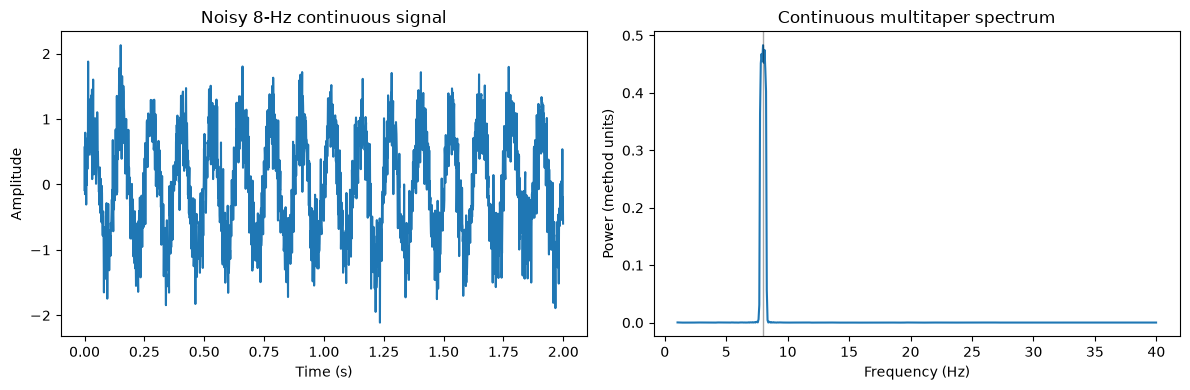

In [8]:
lfp_time = np.arange(n_samples) / fs
lfp = np.sin(2 * np.pi * target_frequency * lfp_time) + 0.35 * rng.normal(
    size=n_samples
)
continuous_tapers = px.dpsschk((NW, n_tapers), n_samples, fs)
continuous_nfft = 2 ** int(np.ceil(np.log2(n_samples)))
continuous_transform = px.mtfftc(lfp, continuous_tapers, continuous_nfft, fs)
continuous_power = px.mtspectrumc(lfp, fs, fpass, (NW, n_tapers))
continuous_peak = float(continuous_power.index[np.argmax(continuous_power.to_numpy())])
assert continuous_transform.shape == (continuous_nfft, n_tapers)
assert abs(continuous_peak - target_frequency) < 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lfp_time[:2_000], lfp[:2_000])
axes[0].set(xlabel="Time (s)", ylabel="Amplitude", title="Noisy 8-Hz continuous signal")
axes[1].plot(continuous_power.index, continuous_power)
axes[1].axvline(target_frequency, color="k", alpha=0.35, lw=1)
axes[1].set(
    xlabel="Frequency (Hz)",
    ylabel="Power (method units)",
    title="Continuous multitaper spectrum",
)
plt.tight_layout()

**Continuous-data caveats.** Detrend or otherwise handle artifacts before spectral estimation when needed; a large drift can dominate low frequencies. Keep the signal and taper lengths identical, and pass a one-dimensional trace to `mtfftc`. For short windows, the time-bandwidth tradeoff is particularly consequential: acquiring or analyzing a longer stationary segment improves true frequency resolution more than increasing `nfft`.

## 4. Real-world example: HP18 day 22

The synthetic examples establish known ground truth. This final workflow applies the high-level estimators to the HP18 session at `U:\data\hpc_ctx_project\HP18\hp18_day22_20250426`. It selects a CA1 stratum oriens (`CA1so`) LFP channel when that annotation is available, chooses one non-sleep behavioral condition, and analyzes matched contiguous 10-second windows. Each window is estimated independently—never by concatenating discontinuous epochs—then `npy.plotting.plot_peth` summarizes the window-level spectra.

The LFP is anti-aliased and resampled to 100 Hz before a 1–40 Hz spectrum is calculated. The spike estimator also uses a 100-Hz interpolation grid; this is sufficient for a 40-Hz upper bound while avoiding the unnecessary cost of the acquisition sampling rate. Set `max_windows` to `None` when a full condition-level estimate is needed.

In [9]:
basepath = Path(r"U:\data\hpc_ctx_project\HP18\hp18_day22_20250426")
if not basepath.is_dir():
    raise FileNotFoundError(
        f"{basepath} is not available. Mount the U: drive to run this real-data section."
    )
# Choose one behavioral condition so the average is not a mixture of states.
epoch_df = npy.io.load_epoch(basepath)
non_sleep_epochs = epoch_df.query("environment != 'sleep'").copy()
if non_sleep_epochs.empty:
    raise RuntimeError("No non-sleep epochs were found.")
non_sleep_epochs["duration"] = non_sleep_epochs.stopTime - non_sleep_epochs.startTime
available_environments = non_sleep_epochs.groupby("environment").duration.sum()
analysis_environment = available_environments.idxmax()
condition_epochs = non_sleep_epochs.query("environment == @analysis_environment")

# Split only contiguous intervals into fixed-length stationary windows.
window_duration = 10.0  # seconds; NW=3 gives 0.3-Hz spectral smoothing
window_starts = [
    np.arange(start, stop - window_duration + 1e-9, window_duration)
    for start, stop in condition_epochs[["startTime", "stopTime"]].to_numpy()
    if stop - start >= window_duration
]
if not window_starts:
    raise RuntimeError(
        f"No {window_duration:g}-s windows are available in {analysis_environment!r}."
    )
analysis_starts = np.concatenate(window_starts)
analysis_windows = np.column_stack((analysis_starts, analysis_starts + window_duration))

# An evenly spaced sample keeps the tutorial responsive. Set None to use every window.
max_windows = 10
if max_windows is not None and len(analysis_windows) > max_windows:
    selected = np.linspace(0, len(analysis_windows) - 1, max_windows, dtype=int)
    analysis_windows = analysis_windows[selected]

# load brain region annotations and select a CA1 stratum oriens channel if available
brain_regions = npy.io.load_brain_regions(str(basepath), out_format="DataFrame")
ca1so = brain_regions.loc[brain_regions.region.eq("CA1so"), "channels"]
lfp_channel = int(ca1so.iloc[0] if not ca1so.empty else brain_regions.channels.iloc[0])

analysis_fs = 100.0  # Hz; safely above twice the 40-Hz upper frequency
fpass_real = [1.0, 40.0]
print(
    f"Analyzing {len(analysis_windows)} × {window_duration:g}-s windows from "
    f"{analysis_environment!r} on channel {lfp_channel}."
)

Analyzing 10 × 10-s windows from 'open_field' on channel 175.


In [10]:
spike_trains_real, cell_metrics = npy.io.load_spikes(str(basepath), brainRegion="CA1")
if spike_trains_real is None or len(spike_trains_real.data) == 0:
    raise RuntimeError("No usable CA1 sorted units were found for this session.")

lfp_spectra = []
spike_spectra = []
for window_number, (window_start, window_stop) in enumerate(analysis_windows, start=1):
    # Load one contiguous LFP window, then anti-alias and resample it.
    window_epoch = nel.EpochArray([[window_start, window_stop]])
    lfp_loader = npy.io.LFPLoader(
        str(basepath), channels=lfp_channel, ext="lfp", epoch=window_epoch
    )
    source_fs = float(lfp_loader.fs)
    resample_ratio = Fraction(analysis_fs / source_fs).limit_denominator()
    resampled_fs = source_fs * resample_ratio.numerator / resample_ratio.denominator
    if not np.isclose(resampled_fs, analysis_fs):
        raise ValueError(
            f"Could not resample {source_fs:g} Hz to {analysis_fs:g} Hz exactly."
        )
    lfp_window = resample_poly(
        np.asarray(lfp_loader.data).squeeze(),
        resample_ratio.numerator,
        resample_ratio.denominator,
    )
    lfp_spectrum = px.mtspectrumc(
        lfp_window, int(analysis_fs), fpass_real, tapers=(3, 5)
    )
    lfp_spectrum.name = f"window_{window_number}"
    lfp_spectra.append(lfp_spectrum)

    # Preserve real within-window timing; do not compress gaps between epochs.
    spikes_in_window = spike_trains_real[window_epoch].data
    unit_times = np.asarray(
        [np.asarray(unit, dtype=float) - window_start for unit in spikes_in_window],
        dtype=object,
    )
    spike_spectrum = px.mtspectrumpt(
        unit_times,
        int(analysis_fs),
        fpass_real,
        NW=3,
        n_tapers=5,
        time_support=[0.0, window_duration],
    )
    spike_spectrum.columns = pd.MultiIndex.from_product(
        [[window_number], spike_spectrum.columns], names=["window", "unit"]
    )
    spike_spectra.append(spike_spectrum)

real_lfp_power = pd.concat(lfp_spectra, axis=1)
real_spike_power = pd.concat(spike_spectra, axis=1)
assert not real_lfp_power.empty and not real_spike_power.empty


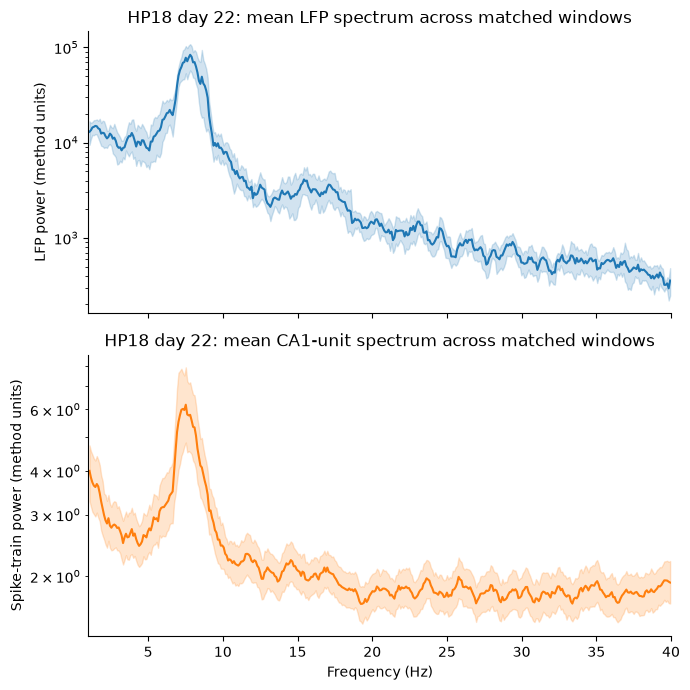

In [11]:
# simplify columns for plotting function
real_spike_power.columns = np.arange(real_spike_power.shape[1])

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
npy.plotting.plot_peth(real_lfp_power, ax=axes[0], color="tab:blue")
axes[0].set(
    ylabel="LFP power (method units)",
    title="HP18 day 22: mean LFP spectrum across matched windows",
)
npy.plotting.plot_peth(real_spike_power, ax=axes[1], color="tab:orange")
axes[1].set(
    xlabel="Frequency (Hz)",
    ylabel="Spike-train power (method units)",
    title="HP18 day 22: mean CA1-unit spectrum across matched windows",
)
for ax in axes:
    ax.set(xlim=fpass_real, yscale="log")
axes[0].set_xlabel("Frequency (Hz)")
plt.tight_layout()

## Decision guide and checklist

- Use `mtspectrumc` for rhythmic content in one continuous trace; use `mtspectrumpt` for one or more spike trains.
- Use `point_spectra` for a simple single-train NumPy result; use `mtspectrumpt` when DataFrame labels, multiple units, or reusable time support are useful.
- Use `mtcsdpt` for unnormalized shared spectral structure and `mtcoherencept` for normalized frequency-specific coupling. Neither implies causal influence.
- Use `getfgrid`, `dpsschk`, `get_tapers`, `mtfftpt`, and `mtfftc` when building a custom estimator or inspecting the computation; otherwise start with the high-level spectrum functions.
- Check units (seconds and Hz), array orientation, support duration, taper count, and the Nyquist limit before interpreting a peak.
- Report the observation duration, `Fs`, `fpass`, `NW`, number of tapers, and any preprocessing alongside scientific results.

## References

- Thomson, D. J. (1982). Spectrum estimation and harmonic analysis. *Proceedings of the IEEE*, 70(9), 1055–1096. https://doi.org/10.1109/PROC.1982.12433
- Mitra, P. P. & Bokil, H. (2008). *Observed Brain Dynamics*. Oxford University Press.
- Chronux: a platform for analyzing neural data. http://chronux.org/